# Forecasting Performance — Sections 7.1–7.3

Generates the model-comparison figures and tables. Reuses helpers in
`organized/src/srwnba/analysis/`. All outputs land in `organized/outputs/`.

**Outputs:**

| File | Purpose |
|---|---|
| `forecast_per_fold_logloss_by_model.png` | Per-fold log-loss across 2020–2024 |
| `forecast_model_performance_summary.csv` | Combined OOF + holdout summary |
| `forecast_brier_score_comparison.png` | Appendix Brier comparison |
| `forecast_per_fold_performance_table.csv` | Appendix per-fold table |
| `forecast_reliability_diagram_oof.png` | Reliability on OOF 2020–2024 |
| `forecast_calibration_bin_table.csv` | Calibration bin counts/rates |
| `forecast_reliability_diagram_holdout.png` | Reliability on 2025 holdout |

In [2]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'figure.dpi': 120})

ANALYSIS_DIR = Path('../..').resolve() / 'src' / 'srwnba' / 'analysis'
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

from outputs import save_fig, save_table
from walkforward import (
    walk_forward_models, fit_holdout_models, summarize_predictions,
    PAPER_MODEL_SPECS, PAPER_MODEL_ORDER, PAPER_MODEL_LABELS, PAPER_MODEL_COLORS,
)
from eval_helpers import reliability_table

OOF_YEARS = list(range(2020, 2025))
HOLDOUT_YEAR = 2025
print(f'Models: {PAPER_MODEL_ORDER}  |  OOF: {OOF_YEARS}  |  Holdout: {HOLDOUT_YEAR}')

Models: ['elo', 'logreg_no_elo', 'xgb_no_elo', 'logreg_with_elo', 'xgb_with_elo']  |  OOF: [2020, 2021, 2022, 2023, 2024]  |  Holdout: 2025


In [3]:
# Walk-forward OOF (2020-2024) — five model specs
oof_df = walk_forward_models(PAPER_MODEL_SPECS, oof_years=OOF_YEARS)
print(f'OOF rows: {len(oof_df):,}  |  unique games: {oof_df["game_id"].nunique()}')

--- Fold: test_year = 2020 ---
  xgb_no_elo               best_round=211
  xgb_with_elo             best_round=10
--- Fold: test_year = 2021 ---
  xgb_no_elo               best_round=238
  xgb_with_elo             best_round=63
--- Fold: test_year = 2022 ---
  xgb_no_elo               best_round=222
  xgb_with_elo             best_round=26
--- Fold: test_year = 2023 ---
  xgb_no_elo               best_round=94
  xgb_with_elo             best_round=25
--- Fold: test_year = 2024 ---
  xgb_no_elo               best_round=188
  xgb_with_elo             best_round=87
OOF rows: 5,585  |  unique games: 1117


In [4]:
# 2025 holdout fit — same five specs
holdout_df, artefacts = fit_holdout_models(PAPER_MODEL_SPECS, holdout_year=HOLDOUT_YEAR)
print(f'Holdout rows: {len(holdout_df):,}  |  unique games: {holdout_df["game_id"].nunique()}')

  xgb_no_elo               best_round=325
  xgb_with_elo             best_round=88
Holdout rows: 1,550  |  unique games: 310


---
## §7.1 — Per-fold model stability
**Figure:** `forecast_per_fold_logloss_by_model`.

  saved: outputs\forecast_per_fold_logloss_by_model.png


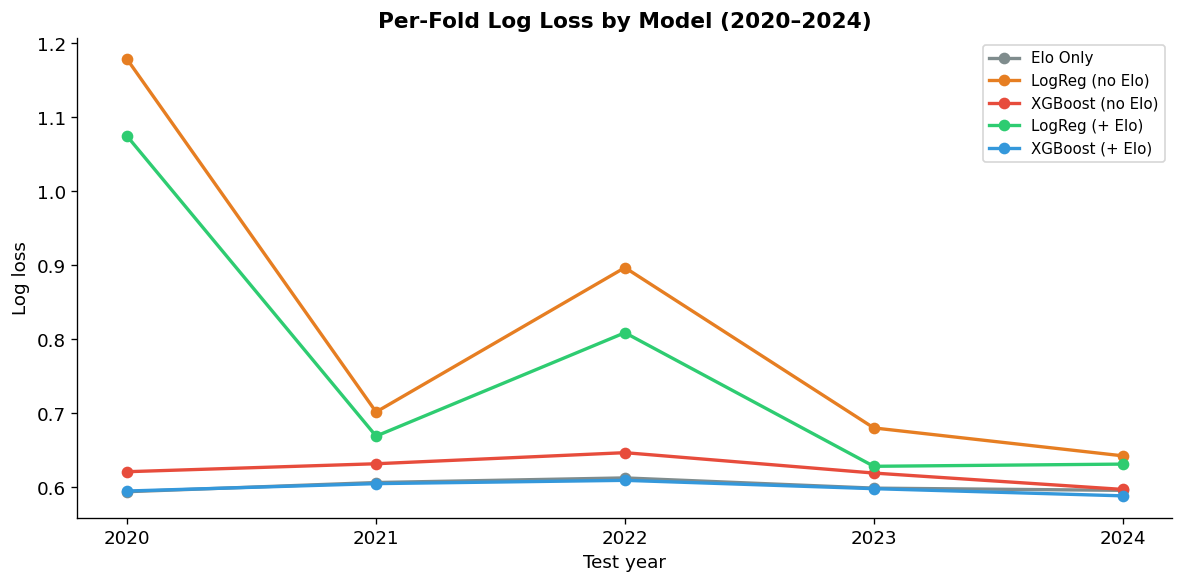

In [5]:
from sklearn.metrics import log_loss

fig, ax = plt.subplots(figsize=(10, 5))
for m in PAPER_MODEL_ORDER:
    ll = []
    for y in OOF_YEARS:
        sub = oof_df[(oof_df['model'] == m) & (oof_df['season'] == y)]
        ll.append(log_loss(sub['home_win'], np.clip(sub['pred_prob'], 1e-7, 1-1e-7)))
    ax.plot(OOF_YEARS, ll, marker='o', linewidth=2, markersize=6,
            label=PAPER_MODEL_LABELS[m], color=PAPER_MODEL_COLORS[m])
ax.set_xlabel('Test year'); ax.set_ylabel('Log loss')
ax.set_title('Per-Fold Log Loss by Model (2020–2024)', fontweight='bold')
ax.set_xticks(OOF_YEARS); ax.legend(fontsize=9, loc='best')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
save_fig(fig, 'forecast_per_fold_logloss_by_model')
plt.show()

---
## §7.2 — Development and holdout summary
**Table:** `forecast_model_performance_summary` — combined OOF + 2025 holdout.

In [6]:
dev = summarize_predictions(oof_df).assign(period='OOF 2020–2024')
hold = summarize_predictions(holdout_df).assign(period='2025 Holdout')

summary = (
    pd.concat([dev, hold], ignore_index=True)
    [['period', 'model', 'log_loss', 'brier', 'accuracy', 'n_games']]
)
model_rank = {m: i for i, m in enumerate(PAPER_MODEL_ORDER)}
summary['_r'] = summary['model'].map(model_rank)
summary = (
    summary.sort_values(['period', '_r']).drop(columns='_r').reset_index(drop=True)
)
save_table(summary, 'forecast_model_performance_summary')
summary

  saved: outputs\forecast_model_performance_summary.csv


,period,model,log_loss,brier,accuracy,n_games
0,2025 Holdout,elo,0.615098,0.213165,0.667742,310
1,2025 Holdout,logreg_no_elo,0.699122,0.242812,0.641935,310
2,2025 Holdout,xgb_no_elo,0.632729,0.218845,0.667742,310
3,2025 Holdout,logreg_with_elo,0.668437,0.233164,0.648387,310
4,2025 Holdout,xgb_with_elo,0.612148,0.211232,0.674194,310
5,OOF 2020–2024,elo,0.602163,0.207240,0.677708,1117
6,OOF 2020–2024,logreg_no_elo,0.787548,0.236073,0.643688,1117
7,OOF 2020–2024,xgb_no_elo,0.622805,0.216548,0.650850,1117
8,OOF 2020–2024,logreg_with_elo,0.734252,0.228492,0.658908,1117
9,OOF 2020–2024,xgb_with_elo,0.599394,0.205496,0.694718,1117


### Appendix — per-fold table
**Table:** `forecast_per_fold_performance_table`.

In [7]:
fold_tbl = summarize_predictions(oof_df, by_fold=True)
fold_tbl['_r'] = fold_tbl['model'].map(model_rank)
fold_tbl = fold_tbl.sort_values(['season', '_r']).drop(columns='_r').reset_index(drop=True)
fold_tbl = fold_tbl.rename(columns={'season': 'fold_year'})
save_table(fold_tbl, 'forecast_per_fold_performance_table')
fold_tbl

  saved: outputs\forecast_per_fold_performance_table.csv


,model,fold_year,log_loss,brier,accuracy,n_games
0,elo,2020,0.594308,0.202210,0.721088,147
1,logreg_no_elo,2020,1.178373,0.276372,0.653061,147
2,xgb_no_elo,2020,0.621327,0.216319,0.639456,147
3,logreg_with_elo,2020,1.074460,0.272305,0.646259,147
4,xgb_with_elo,2020,0.595243,0.202632,0.721088,147
5,elo,2021,0.606694,0.211113,0.645933,209
6,logreg_no_elo,2021,0.702022,0.230019,0.636364,209
7,xgb_no_elo,2021,0.632079,0.221694,0.598086,209
8,logreg_with_elo,2021,0.669425,0.225549,0.641148,209
9,xgb_with_elo,2021,0.605204,0.210446,0.665072,209


### Appendix — Brier score comparison
**Figure:** `forecast_brier_score_comparison`.

  saved: outputs\forecast_brier_score_comparison.png


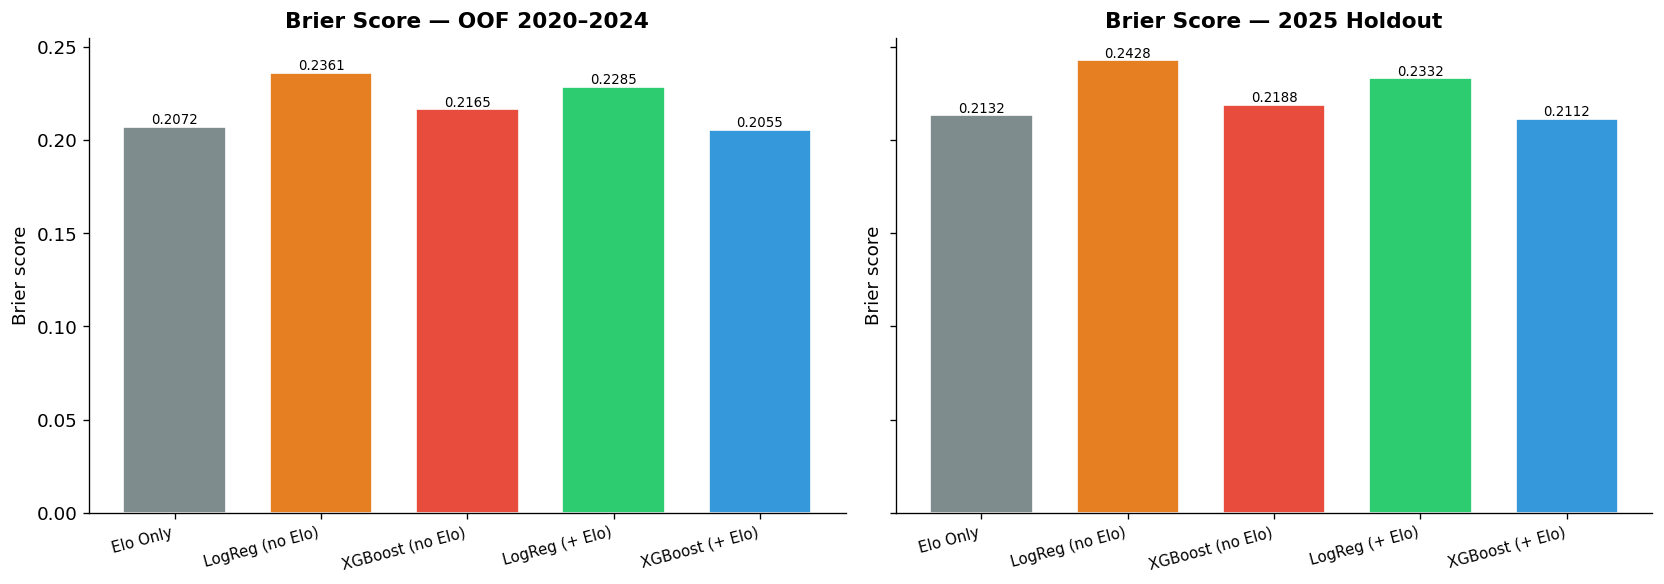

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, period in zip(axes, ('OOF 2020–2024', '2025 Holdout')):
    sub = summary[summary['period'] == period]
    sub = sub.set_index('model').loc[PAPER_MODEL_ORDER]
    colors = [PAPER_MODEL_COLORS[m] for m in PAPER_MODEL_ORDER]
    bars = ax.bar(range(len(sub)), sub['brier'].values, color=colors, edgecolor='white', width=0.7)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels([PAPER_MODEL_LABELS[m] for m in PAPER_MODEL_ORDER],
                       rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Brier score')
    ax.set_title(f'Brier Score — {period}', fontweight='bold')
    for bar, val in zip(bars, sub['brier'].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
save_fig(fig, 'forecast_brier_score_comparison')
plt.show()

---
## §7.3 — Reliability / calibration
**Figure:** `forecast_reliability_diagram_oof`.

  saved: outputs\forecast_reliability_diagram_oof.png


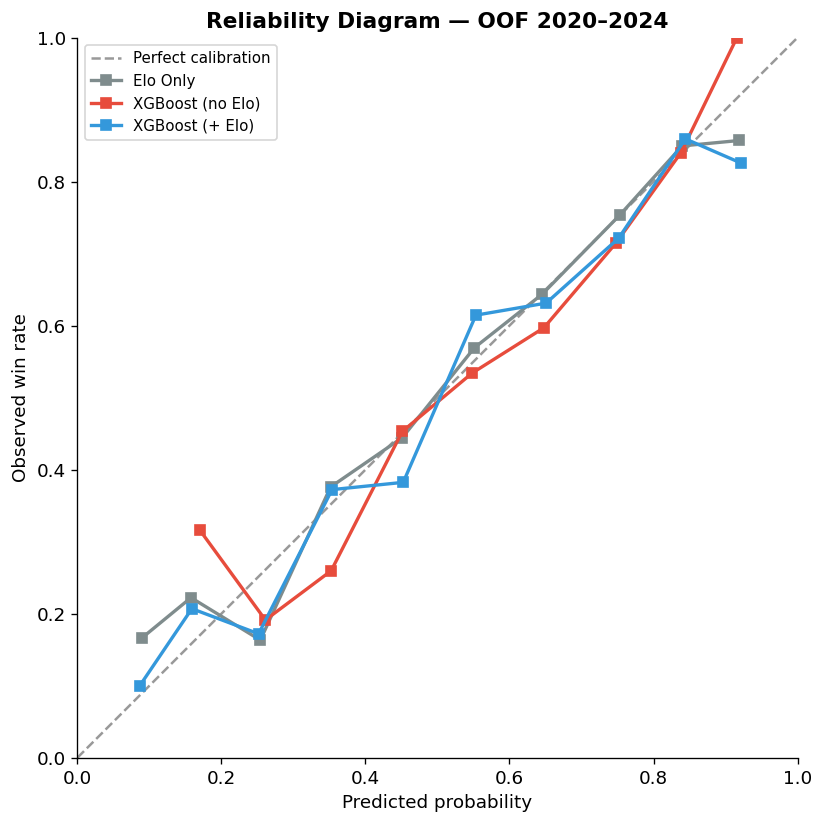

In [9]:
RELIABILITY_MODELS = ['elo', 'xgb_no_elo', 'xgb_with_elo']

def plot_reliability(ax, df, title):
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
    for m in RELIABILITY_MODELS:
        sub = df[df['model'] == m]
        rel = reliability_table(sub['home_win'].values, sub['pred_prob'].values, n_bins=10)
        ax.plot(rel['mean_pred'], rel['observed_rate'], marker='s',
                color=PAPER_MODEL_COLORS[m], label=PAPER_MODEL_LABELS[m],
                linewidth=2, markersize=6)
    ax.set_xlabel('Predicted probability'); ax.set_ylabel('Observed win rate')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig, ax = plt.subplots(figsize=(7, 7))
plot_reliability(ax, oof_df, 'Reliability Diagram — OOF 2020–2024')
plt.tight_layout()
save_fig(fig, 'forecast_reliability_diagram_oof')
plt.show()

### Appendix — calibration bin table
**Table:** `forecast_calibration_bin_table` — one row per (model × bin) on OOF predictions.

In [10]:
rows = []
for m in RELIABILITY_MODELS:
    sub = oof_df[oof_df['model'] == m]
    rel = reliability_table(sub['home_win'].values, sub['pred_prob'].values, n_bins=10)
    rel.insert(0, 'model', m)
    rows.append(rel)
calib_tbl = pd.concat(rows, ignore_index=True)
save_table(calib_tbl, 'forecast_calibration_bin_table')
calib_tbl

  saved: outputs\forecast_calibration_bin_table.csv


,model,bin_lo,bin_hi,mean_pred,observed_rate,n
0,elo,0.0,0.1,0.090040,0.166667,6
1,elo,0.1,0.2,0.157689,0.222222,63
2,elo,0.2,0.3,0.253955,0.163265,98
3,elo,0.3,0.4,0.351521,0.375887,141
4,elo,0.4,0.5,0.451084,0.444444,171
5,elo,0.5,0.6,0.551195,0.569231,195
6,elo,0.6,0.7,0.645433,0.643678,174
7,elo,0.7,0.8,0.753110,0.753521,142
8,elo,0.8,0.9,0.839803,0.849558,113
9,elo,0.9,1.0,0.919354,0.857143,14


### Appendix — holdout reliability diagram
**Figure:** `forecast_reliability_diagram_holdout`.

  saved: outputs\forecast_reliability_diagram_holdout.png


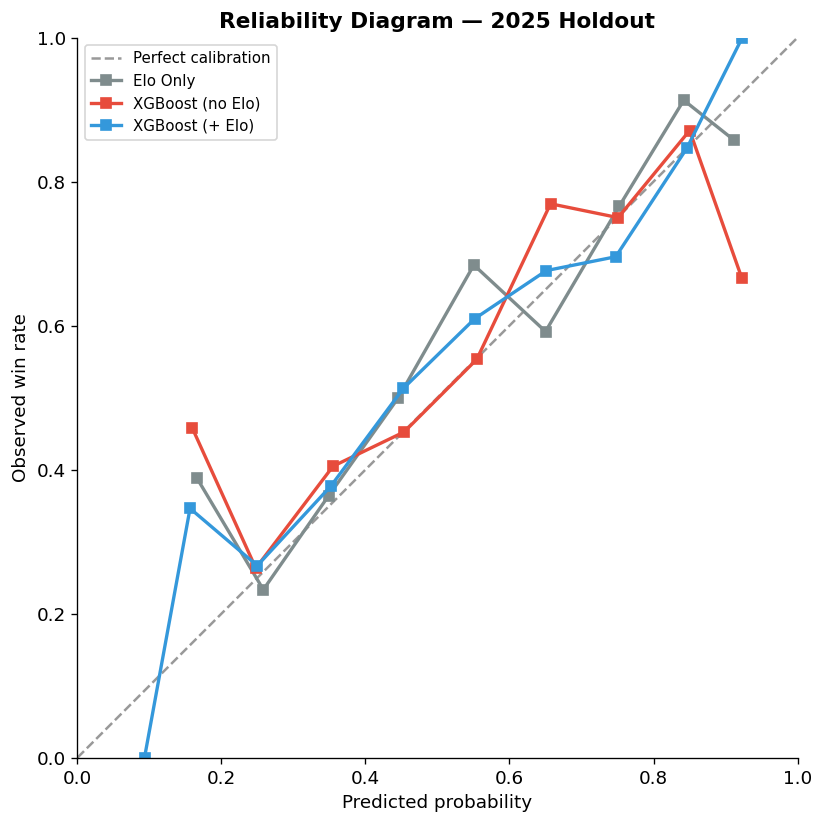

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))
plot_reliability(ax, holdout_df, 'Reliability Diagram — 2025 Holdout')
plt.tight_layout()
save_fig(fig, 'forecast_reliability_diagram_holdout')
plt.show()